# 02 · Data preprocessing

Builds a **leakage-free** train/val/test split and a TensorFlow `tf.data` input
pipeline for ResNet50 (224×224). No model is trained here and no image files are
copied: the splits are CSV manifests of paths into `Dataset/raw/`.

Why the dataset is re-split (see notebook 01):
* augmented copies of the same leaf are spread across `train/` and `valid/`;
* the supplied `test/` images are byte copies of `valid/` images.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 140)

# Chart styling: light surface, recessive axes, fixed categorical order.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]   # train, val/valid, test
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#b5b4ad", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "text.color": "#0b0b0b",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "font.size": 9, "axes.titlesize": 11, "axes.titleweight": "bold",
})

import time
import tensorflow as tf

from src.preprocessing import config, splits, pipeline

tf.keras.utils.set_random_seed(config.SEED)
print("TensorFlow", tf.__version__, "| Keras", tf.keras.__version__)
print("Image size:", config.IMAGE_SIZE, "| batch:", config.BATCH_SIZE, "| seed:", config.SEED)
print("Split ratios:", config.SPLIT_RATIOS)

TensorFlow 2.21.0 | Keras 3.15.1
Image size: (224, 224) | batch: 32 | seed: 42
Split ratios: {'train': 0.8, 'val': 0.1, 'test': 0.1}


## 1 · Group images by physical leaf and split

Images are linked into one group if they share a source leaf name (UUID prefix and
augmentation suffix removed), a UUID, identical bytes or an identical perceptual
hash. Whole groups are assigned to a split, class by class, so the split is
stratified and no leaf appears in two splits.

In [2]:
manifest, class_names, report, supplied_test = splits.build_splits()
print(json.dumps(report, indent=2))

{
  "seed": 42,
  "ratios": {
    "train": 0.8,
    "val": 0.1,
    "test": 0.1
  },
  "images_in_pool": 52714,
  "exact_duplicates_dropped": 5,
  "images_after_dedup": 52709,
  "num_groups": 33557,
  "largest_group": 14,
  "split_sizes": {
    "train": 42114,
    "val": 5304,
    "test": 5291
  },
  "split_fractions": {
    "train": 0.799,
    "val": 0.1006,
    "test": 0.1004
  },
  "supplied_test_images_excluded": 33,
  "supplied_test_twin_splits": {
    "train": 26,
    "test": 4,
    "val": 3
  }
}


## 2 · Leakage checks

In [3]:
leaks = splits.check_no_leakage(manifest)
print("Values shared between splits:", leaks)
assert all(v == 0 for v in leaks.values()), "leakage detected"

paths_per_split = [set(manifest.loc[manifest["split"] == s, "path"]) for s in config.SPLIT_RATIOS]
assert not (paths_per_split[0] & paths_per_split[1] or paths_per_split[0] & paths_per_split[2]
            or paths_per_split[1] & paths_per_split[2])
assert manifest["md5"].is_unique
assert manifest.groupby("group_id")["label"].nunique().max() == 1, "a group spans classes"
print("OK: no shared files, hashes, near-duplicates or source leaves across splits")

Values shared between splits: {'group_id': 0, 'md5': 0, 'phash': 0, 'leaf_key': 0}
OK: no shared files, hashes, near-duplicates or source leaves across splits


In [4]:
print("Supplied test/ images are excluded from all splits (duplicates of labelled files).")
print("Split holding each one's identical twin:", supplied_test["twin_split"].value_counts().to_dict())

Supplied test/ images are excluded from all splits (duplicates of labelled files).
Split holding each one's identical twin: {'train': 26, 'test': 4, 'val': 3}


## 3 · Class balance per split

In [5]:
per_class = splits.summarise_per_class(manifest)
fractions = per_class.div(per_class.sum(axis=1), axis=0)
print("Per-class split fraction range:")
print(fractions.agg(["min", "max"]).round(3))
assert per_class.shape[0] == 38 and (per_class > 0).all().all()
per_class

Per-class split fraction range:
split  train    val   test
min    0.795  0.100  0.099
max    0.800  0.103  0.102


split,train,val,test
label,,,
Apple___Apple_scab,1207,153,152
Apple___Black_rot,1191,149,151
Apple___Cedar_apple_rust,1051,134,135
Apple___healthy,1201,151,151
Blueberry___healthy,1088,136,138
Cherry_(including_sour)___Powdery_mildew,1010,127,126
Cherry_(including_sour)___healthy,1094,138,137
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,977,125,122
Corn_(maize)___Common_rust_,1145,143,143


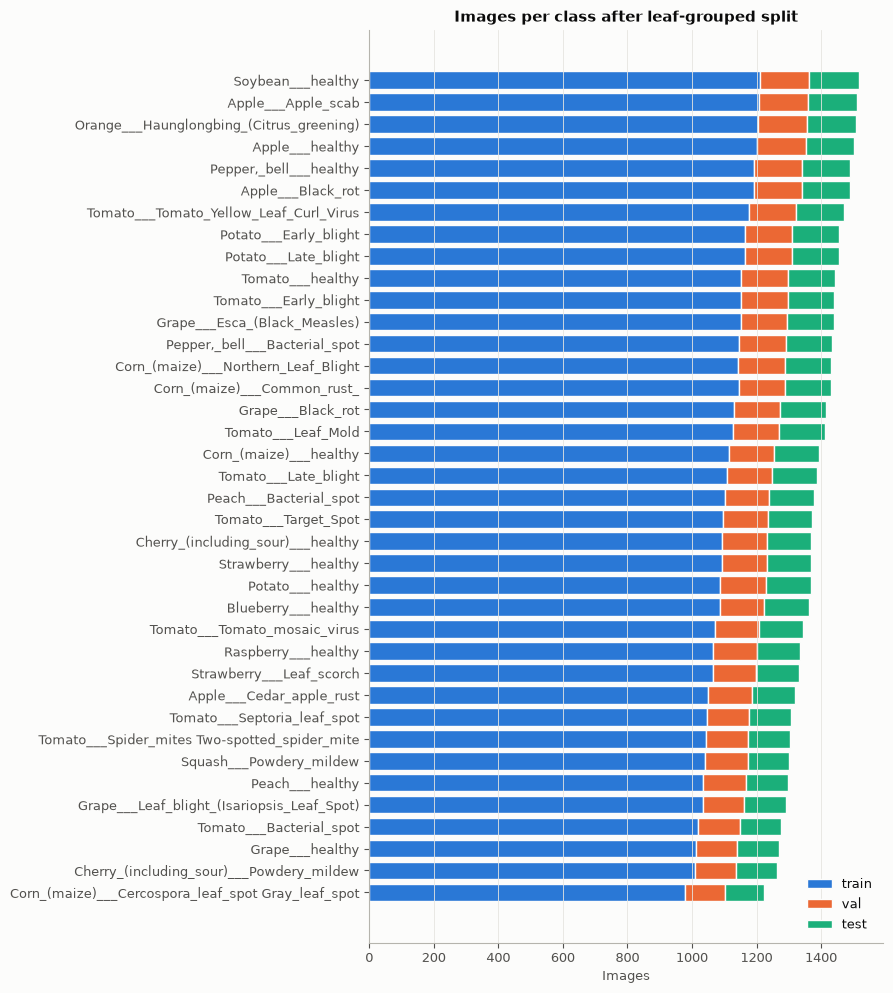

In [6]:
order = per_class.sum(axis=1).sort_values().index
fig, ax = plt.subplots(figsize=(9, 10))
y = np.arange(len(order))
left = np.zeros(len(order))
for color, split in zip(SERIES, config.SPLIT_RATIOS):
    values = per_class.loc[order, split].to_numpy()
    ax.barh(y, values, left=left, color=color, height=0.8, label=split,
            edgecolor="#fcfcfb", linewidth=1)
    left += values
ax.set_yticks(y, order)
ax.set_xlabel("Images")
ax.set_title("Images per class after leaf-grouped split")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
fig.savefig(config.PLOTS_DIR / "02_split_per_class.png", dpi=120)
plt.show()

## 4 · Save manifests

In [7]:
splits.save_splits(manifest, class_names, report, supplied_test)
for f in sorted(config.SPLITS_DIR.iterdir()):
    print(f"{f.name:32s} {f.stat().st_size / 1024:8.1f} KB")

class_names.json                      1.2 KB
split_report.json                     0.5 KB
supplied_test_samples.csv             2.5 KB
test.csv                           1010.9 KB
train.csv                          8049.4 KB
val.csv                            1013.4 KB


## 5 · The tf.data pipeline

| Step | train | val / test |
|---|---|---|
| shuffle (whole split, reshuffled every epoch) | ✓ | – |
| read → decode JPEG (RGB) → resize to 224×224 (bilinear, antialiased) | ✓ | ✓ |
| batch (32) | ✓ | ✓ |
| random flip (H+V), rotation ±10 %, zoom ±10 %, translation ±10 %, brightness ±10 %, contrast ±10 % | ✓ | – |
| `resnet50.preprocess_input` (RGB→BGR, subtract ImageNet mean) | ✓ | ✓ |
| prefetch | ✓ | ✓ |

`preprocess_input` uses fixed ImageNet statistics, so nothing is fitted on the data.

In [8]:
train_ds = pipeline.make_dataset("train")
val_ds = pipeline.make_dataset("val")
test_ds = pipeline.make_dataset("test")
print(train_ds.element_spec)
class_names = splits.load_class_names()
print(len(class_names), "classes; index 0 =", class_names[0], "| index 37 =", class_names[-1])

(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
38 classes; index 0 = Apple___Apple_scab | index 37 = Tomato___healthy


## 6 · Verify batch shapes, dtypes and value ranges

In [9]:
for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    x, y = next(iter(ds))
    x = x.numpy()
    print(f"{name:5s} x{tuple(x.shape)} {x.dtype}  y{tuple(y.shape)} {y.dtype}  "
          f"range [{x.min():7.2f}, {x.max():7.2f}]  "
          f"channel means (BGR) {np.round(x.mean(axis=(0, 1, 2)), 1)}  "
          f"labels {y.numpy().min()}-{y.numpy().max()}")
    assert x.shape[1:] == (224, 224, 3) and x.dtype == np.float32
    assert y.dtype == tf.int32 and 0 <= y.numpy().min() and y.numpy().max() < 38
    # caffe-mode bounds: 0 - max(mean) .. 255 - min(mean)
    assert x.min() >= -123.68 - 1e-3 and x.max() <= 255 - 103.939 + 1e-3

train x(32, 224, 224, 3) float32  y(32,) <dtype: 'int32'>  range [-123.68,  151.06]  channel means (BGR) [-3.7  7.1 -8.6]  labels 0-36


val   x(32, 224, 224, 3) float32  y(32,) <dtype: 'int32'>  range [-123.68,  151.06]  channel means (BGR) [-12.7 -12.3 -29.9]  labels 0-0


test  x(32, 224, 224, 3) float32  y(32,) <dtype: 'int32'>  range [-123.68,  151.06]  channel means (BGR) [ -1.4  -6.4 -25.6]  labels 0-0


## 7 · Verify preprocessing against an independent reference

In [10]:
from PIL import Image

val_df = splits.load_split("val")
row = val_df.iloc[0]
ref = Image.open(ROOT / row["path"]).convert("RGB")
ref = np.asarray(ref, dtype=np.float32)
ref = tf.image.resize(ref, config.IMAGE_SIZE, antialias=True).numpy()
ref_bgr = ref[..., ::-1] - np.array([103.939, 116.779, 123.68], dtype=np.float32)

x_val, y_val = next(iter(pipeline.make_dataset("val", batch_size=1)))
single = pipeline.preprocess_image_file(ROOT / row["path"])
print("label:", class_names[int(y_val[0])], "| manifest label:", row["label"])
print("max |pipeline - reference|:", float(np.abs(x_val[0].numpy() - ref_bgr).max()))
print("max |pipeline - single-image inference path|:", float(np.abs(x_val.numpy() - single.numpy()).max()))
assert class_names[int(y_val[0])] == row["label"]
assert np.allclose(x_val[0].numpy(), ref_bgr, atol=1.0)
assert np.allclose(x_val.numpy(), single.numpy(), atol=1e-4)

label: Apple___Apple_scab | manifest label: Apple___Apple_scab
max |pipeline - reference|: 0.0
max |pipeline - single-image inference path|: 0.0


## 8 · Determinism: val/test fixed, train randomised

In [11]:
a = np.concatenate([x.numpy() for x, _ in val_ds.take(3)])
b = np.concatenate([x.numpy() for x, _ in val_ds.take(3)])
print("val identical across passes:", np.array_equal(a, b))
assert np.array_equal(a, b)

ya = np.concatenate([y.numpy() for _, y in train_ds.take(3)])
yb = np.concatenate([y.numpy() for _, y in train_ds.take(3)])
print("train order differs across passes:", not np.array_equal(ya, yb))
assert not np.array_equal(ya, yb)

val identical across passes: True


train order differs across passes: True


## 9 · Augmentation examples (train only)

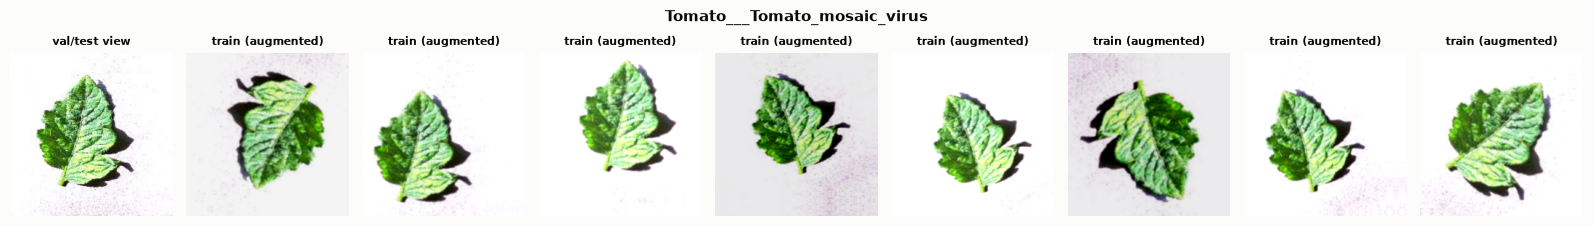

In [12]:
one = splits.load_split("train").sample(1, random_state=config.SEED)
aug_ds = pipeline.make_dataset("train", batch_size=1, manifest=pd.concat([one] * 8))
clean = pipeline.to_display(pipeline.make_dataset("val", batch_size=1, manifest=one).get_single_element()[0])

fig, axes = plt.subplots(1, 9, figsize=(16, 2.3))
axes[0].imshow(clean[0]); axes[0].set_title("val/test view", fontsize=8)
for ax, (x, _) in zip(axes[1:], aug_ds):
    ax.imshow(pipeline.to_display(x)[0]); ax.set_title("train (augmented)", fontsize=8)
for ax in axes:
    ax.axis("off")
fig.suptitle(one["label"].iloc[0], fontweight="bold")
fig.tight_layout()
fig.savefig(config.PLOTS_DIR / "02_augmentation_examples.png", dpi=100)
plt.show()

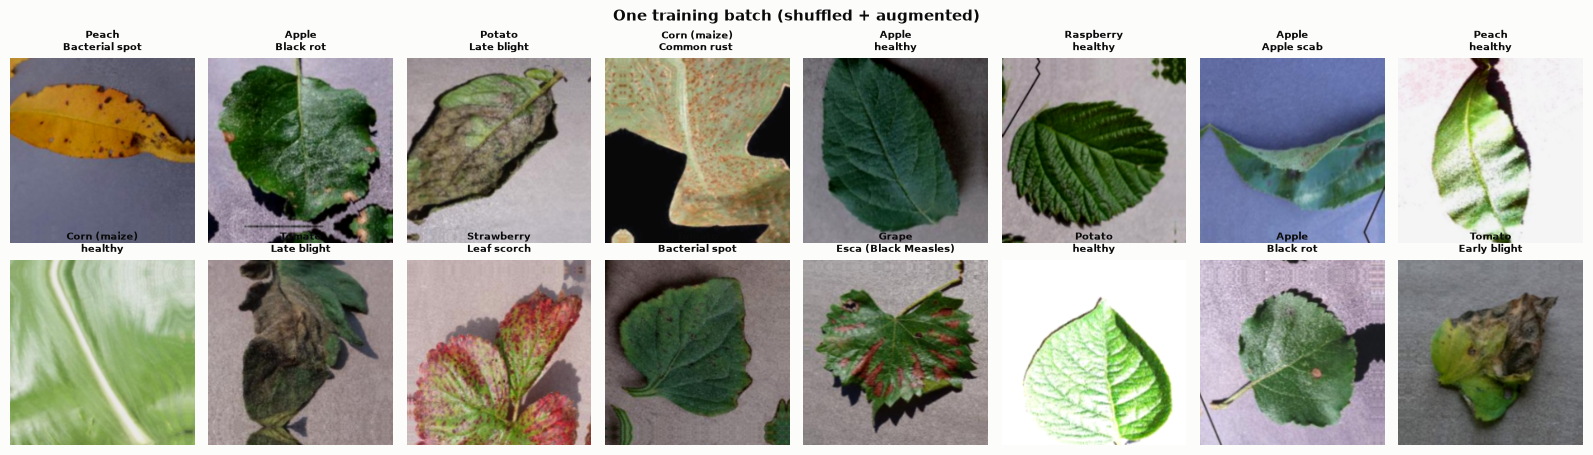

In [13]:
x, y = next(iter(train_ds))
imgs = pipeline.to_display(x).numpy()
fig, axes = plt.subplots(2, 8, figsize=(16, 4.6))
for ax, img, label in zip(axes.flat, imgs, y.numpy()):
    ax.imshow(img); ax.axis("off")
    ax.set_title(class_names[label].replace("___", "\n").replace("_", " ")[:36], fontsize=7)
fig.suptitle("One training batch (shuffled + augmented)", fontweight="bold")
fig.tight_layout()
plt.show()

## 10 · Full pass: every image in every split decodes through TensorFlow

In [14]:
counts = {}
for split in config.SPLIT_RATIOS:
    n, t0 = 0, time.perf_counter()
    for x, y in pipeline.make_dataset(split, batch_size=256, training=False):
        assert np.isfinite(x.numpy()).all()
        n += int(x.shape[0])
    counts[split] = n
    print(f"{split:5s} {n:6,d} images decoded in {time.perf_counter() - t0:5.1f}s")
    assert n == len(splits.load_split(split))

train 42,114 images decoded in  63.4s


val    5,304 images decoded in   8.3s


test   5,291 images decoded in   8.2s


In [15]:
n, t0 = 0, time.perf_counter()
for x, _ in train_ds.take(50):
    n += int(x.shape[0])
print(f"Augmented training throughput: {n / (time.perf_counter() - t0):.0f} images/s on CPU")

Augmented training throughput: 211 images/s on CPU


## Summary

* Train, val and test come from `Dataset/raw/train` + `valid` pooled, deduplicated,
  and split **by physical leaf** (80/10/10, stratified per class). No file, hash,
  near-duplicate or source leaf is shared between splits.
* The supplied `test/` folder is excluded from evaluation; it duplicates labelled files.
* Every image is resized to 224×224 and passed through `resnet50.preprocess_input`;
  training batches are additionally shuffled and augmented.
* val/test preprocessing is deterministic and identical to the single-image
  inference path (`pipeline.preprocess_image_file`).

Outputs: `data/splits/{train,val,test}.csv`, `class_names.json`, `split_report.json`,
`supplied_test_samples.csv`.